# Exploratory Data Analysis — Data Analyst Job Postings (Google Search)

Updated to match the actual columns in `gsearch_jobs_Temp.csv` — this is the
**raw** scrape output (not a pre-cleaned version), so several things are
messier than a typical "clean" dataset:

- Dates aren't absolute — `posted_at` is a relative string like `"15 hours ago"`.
- Skills live in `description_tokens`, stored as a string that looks like a list.
- Extra job attributes (health insurance, no-degree-mentioned, work-from-home,
  schedule type, salary text) are all bundled together inside one `extensions`
  column as a string-list, rather than being separate columns.
- There are two leftover index columns (`Unnamed: 0`, `index`) — an artifact of
  the file being saved with a pandas index more than once.
- **In this sample, the vast majority of rows are completely blank** (no title,
  no company, nothing) — only a handful of rows actually contain a job posting.
  That may just be an artifact of this particular sample/export; the steps
  below will show you exactly how much of your real file is affected once you
  load the full dataset.

Steps covered, same order as before:

1. Shape, dtypes, and memory footprint
2. Missing values (count and %) per column, including how many rows are fully blank
3. Duplicate rows (on the full row, and on `job_id`)
4. Understanding the date/recency fields (`posted_at`, `date_time`)
5. Value counts for key categorical columns
6. Parsing `description_tokens` (skills) and `extensions` (benefits/flags)
7. Numeric summary (min/max/mean/median) and outlier check for the salary columns
8. A couple of quick cross-tabs to see how fields interact

**Before running:** update `CSV_PATH` below to point to your file.


In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import ast  # safely parse string-encoded lists, e.g. "['sql', 'python']"
import re   # pattern-match the free-text fields (posted_at, extensions)
import matplotlib.pyplot as plt  # a few quick structural/distribution charts below

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 100)


In [2]:
# --- Load the data ---
CSV_PATH = "../raw/gsearch_jobs.csv"  # relative to notebooks/, matching the project folder structure

# Column name constants, matching the raw scrape schema. If your file's headers
# differ slightly, you only need to update them here.
COL_TITLE        = "title"
COL_COMPANY      = "company_name"
COL_LOCATION     = "location"
COL_VIA          = "via"                  # e.g. "via LinkedIn" — has a "via " prefix
COL_DESCRIPTION  = "description"
COL_EXTENSIONS   = "extensions"           # string-list of misc tags: time posted, salary text, benefits, schedule type
COL_JOB_ID       = "job_id"
COL_POSTED_AT    = "posted_at"            # relative string, e.g. "15 hours ago" — NOT an absolute date
COL_SCHEDULE     = "schedule_type"
COL_WFH          = "work_from_home"       # only True or NaN in this file (no explicit False)
COL_SALARY_TEXT  = "salary"               # raw text, e.g. "101K-143K a year"
COL_SEARCH_TERM  = "search_term"
COL_DATE_TIME    = "date_time"            # looks unreliable in this sample — see Step 4
COL_SEARCH_LOC   = "search_location"
COL_COMMUTE      = "commute_time"
COL_SALARY_PAY   = "salary_pay"
COL_SALARY_RATE  = "salary_rate"
COL_SALARY_AVG   = "salary_avg"
COL_SALARY_MIN   = "salary_min"
COL_SALARY_MAX   = "salary_max"
COL_SALARY_HOUR  = "salary_hourly"
COL_SALARY_YEAR  = "salary_yearly"
COL_SALARY_STD   = "salary_standardized"
COL_SKILLS       = "description_tokens"   # string-list of skills, e.g. "['sql', 'python']"

# pandas needs low_memory=False here because a few columns mix types across
# the (mostly blank) rows, which otherwise triggers a DtypeWarning.
df = pd.read_csv(CSV_PATH, low_memory=False)

expected_cols = [COL_TITLE, COL_COMPANY, COL_LOCATION, COL_VIA, COL_DESCRIPTION,
                  COL_EXTENSIONS, COL_JOB_ID, COL_POSTED_AT, COL_SCHEDULE, COL_WFH,
                  COL_SALARY_TEXT, COL_SEARCH_TERM, COL_DATE_TIME, COL_SEARCH_LOC,
                  COL_COMMUTE, COL_SALARY_PAY, COL_SALARY_RATE, COL_SALARY_AVG,
                  COL_SALARY_MIN, COL_SALARY_MAX, COL_SALARY_HOUR, COL_SALARY_YEAR,
                  COL_SALARY_STD, COL_SKILLS]
missing_cols = [c for c in expected_cols if c not in df.columns]
print("Columns in file:", df.columns.tolist())
print("Expected columns not found:", missing_cols if missing_cols else "none — all present")


Columns in file: ['Unnamed: 0', 'index', 'title', 'company_name', 'location', 'via', 'description', 'extensions', 'job_id', 'thumbnail', 'posted_at', 'schedule_type', 'work_from_home', 'salary', 'search_term', 'date_time', 'search_location', 'commute_time', 'salary_pay', 'salary_rate', 'salary_avg', 'salary_min', 'salary_max', 'salary_hourly', 'salary_yearly', 'salary_standardized', 'description_tokens']
Expected columns not found: none — all present


## Step 1 — Shape, data types, memory footprint, and a cleanup pass

`Unnamed: 0` and `index` are both leftover row-number columns (a common
artifact of saving a CSV with `to_csv()` — or `reset_index()` — without
`index=False`). They carry no information beyond row position, so they're
dropped here rather than treated as real data.

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n--- Data types per column ---")
print(df.dtypes)

print("\n--- Full summary (dtype, non-null count, memory) ---")
df.info(memory_usage="deep")


Rows: 61,953
Columns: 27

--- Data types per column ---
Unnamed: 0               int64
index                    int64
title                   object
company_name            object
location                object
via                     object
description             object
extensions              object
job_id                  object
thumbnail               object
posted_at               object
schedule_type           object
work_from_home          object
salary                  object
search_term             object
date_time               object
search_location         object
commute_time           float64
salary_pay              object
salary_rate             object
salary_avg             float64
salary_min             float64
salary_max             float64
salary_hourly          float64
salary_yearly          float64
salary_standardized    float64
description_tokens      object
dtype: object

--- Full summary (dtype, non-null count, memory) ---
<class 'pandas.core.frame.DataFrame'>
R

In [4]:
# Drop the redundant index-artifact columns, if present.
junk_index_cols = [c for c in ["Unnamed: 0", "index"] if c in df.columns]
if junk_index_cols:
    print(f"Dropping redundant index columns: {junk_index_cols}")
    df = df.drop(columns=junk_index_cols)

# Quick numeric overview (min / max / mean / etc.) for whatever pandas currently
# sees as numeric — mainly the salary_* fields and commute_time in this dataset.
df.describe(include=[np.number]).T


Dropping redundant index columns: ['Unnamed: 0', 'index']


,count,mean,std,min,25%,50%,75%,max
commute_time,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_avg,10088.0,42100.231239,55893.993519,7.25,31.500,60.0,92500.0,550000.0
salary_min,9512.0,34846.281874,45843.034891,8.00,19.520,50.0,77000.0,450000.0
salary_max,9512.0,50487.856787,67366.522273,10.00,45.000,75.0,110000.0,850000.0
salary_hourly,5900.0,40.539588,22.214540,7.25,23.265,33.5,55.0,300.0
salary_yearly,4069.0,104115.406718,36024.388492,29289.84,80000.180,96500.0,120000.0,550000.0
salary_standardized,10088.0,92289.425683,43277.933820,15080.00,62400.000,88400.0,117500.0,624000.0


## Step 2 — Missing data

Two things to check here: the ordinary per-column null rate, **and** whether
some rows are missing *everything* (no title, no company — i.e. not a real
posting at all). A dataset that's mostly blank rows will show every column as
almost 100% missing, which means something different than a single sparse
column would.

In [5]:
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

missing_summary


,missing_count,missing_pct
commute_time,61953,100.00
salary_yearly,57884,93.43
salary_hourly,56053,90.48
salary_min,52441,84.65
salary_max,52441,84.65
salary_pay,51865,83.72
salary_avg,51865,83.72
salary_standardized,51865,83.72
salary_rate,51865,83.72
salary,51865,83.72


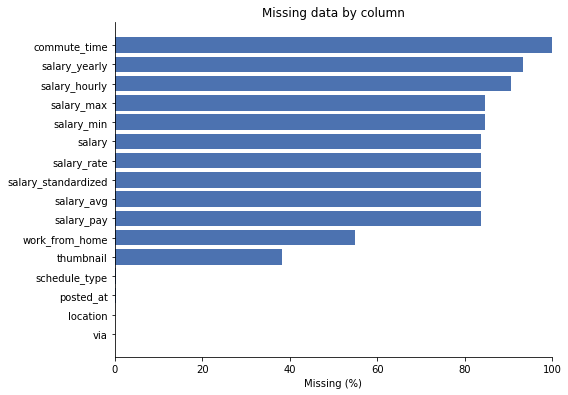

In [6]:
# Same table as above, as a bar chart — easier to scan at a glance once
# there are 20+ columns than a sorted table of numbers. Only columns with
# at least some missing data are shown; fully-populated columns would just
# clutter the chart with zero-length bars.
missing_to_plot = missing_summary.loc[missing_summary["missing_pct"] > 0, "missing_pct"]
missing_to_plot = missing_to_plot.sort_values()  # ascending, so the worst column ends up at the top of the chart

fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(missing_to_plot))))
ax.barh(missing_to_plot.index, missing_to_plot.values, color="#4C72B0")
ax.set_xlabel("Missing (%)")
ax.set_title("Missing data by column")
ax.set_xlim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


In [7]:
# A row with no title isn't a real job posting — it's blank/padding.
# Checking this count tells you whether the high missing-% above is because
# individual fields are sparse, or because whole rows are empty.
blank_rows = df[COL_TITLE].isna().sum()
print(f"Rows with no job title (likely blank/padding rows): {blank_rows:,} of {len(df):,} "
      f"({blank_rows / len(df) * 100:.1f}%)")

# From here on, most steps only make sense on rows that are actual postings,
# so we branch off a filtered copy. The raw `df` (with blank rows included) is
# kept as-is for the file-level checks above and the duplicate check below,
# since those describe the file exactly as it loaded.
df_real = df[df[COL_TITLE].notna()].copy()
print(f"Rows that look like real postings: {len(df_real):,}")


Rows with no job title (likely blank/padding rows): 0 of 61,953 (0.0%)
Rows that look like real postings: 61,953


In [8]:
# Before cleaning anything, check which text columns actually have
# leading/trailing whitespace, and how many values are affected — so you can
# see exactly what's there rather than stripping blindly and never knowing
# what it changed.
string_cols = df_real.select_dtypes(include="object").columns

whitespace_report = {}
for col in string_cols:
    series = df_real[col]
    try:
        has_whitespace = series.notna() & (series != series.str.strip())
    except AttributeError:
        # A few "object" columns (e.g. work_from_home) actually hold booleans
        # rather than text, so the .str accessor doesn't apply — skip those.
        continue
    count = int(has_whitespace.sum())
    if count > 0:
        whitespace_report[col] = count

if whitespace_report:
    print("Columns with leading/trailing whitespace found (count of affected values):")
    for col, count in sorted(whitespace_report.items(), key=lambda x: -x[1]):
        pct = count / len(df_real) * 100
        print(f"  {col}: {count:,} ({pct:.1f}% of rows)")
else:
    print("No leading/trailing whitespace found in any text column.")


Columns with leading/trailing whitespace found (count of affected values):
  location: 36,641 (59.1% of rows)
  description: 1,356 (2.2% of rows)


In [9]:
# Real-world CSVs often pad text values with stray leading/trailing whitespace
# (e.g. "Anywhere" vs " Anywhere " landing as two different values in a
# value_counts()). Strip every text column now, once, so duplicate checks,
# date parsing, and categorical grouping below all benefit — rather than
# fixing it one column at a time as it turns up.
stripped_cols = []
for col in string_cols:
    try:
        df_real[col] = df_real[col].str.strip()
        stripped_cols.append(col)
    except AttributeError:
        continue

print(f"Stripped leading/trailing whitespace from {len(stripped_cols)} text columns:")
print(stripped_cols)


Stripped leading/trailing whitespace from 17 text columns:
['title', 'company_name', 'location', 'via', 'description', 'extensions', 'job_id', 'thumbnail', 'posted_at', 'schedule_type', 'salary', 'search_term', 'date_time', 'search_location', 'salary_pay', 'salary_rate', 'description_tokens']


## Step 3 — Duplicate rows

In [10]:
# On the raw file: fully duplicated rows (every column identical). If most
# rows are blank (see Step 2), you'd expect nearly all of them to show up here,
# since blank rows are indistinguishable from each other.
full_dupe_count = df.duplicated().sum()
print(f"Fully duplicated rows (raw file): {full_dupe_count:,}")

# job_id is the closest thing this dataset has to a natural primary key for a
# posting. Checking duplicates on just that column, restricted to real postings,
# is a more meaningful signal than the full-row check above.
real_dupe_on_id = df_real.duplicated(subset=[COL_JOB_ID]).sum()
print(f"Duplicated job_id among real postings: {real_dupe_on_id:,} of {len(df_real):,}")

# Peek at a few duplicates on the real subset, if any exist
df_real[df_real.duplicated(subset=[COL_JOB_ID], keep=False)].sort_values(COL_JOB_ID).head(10)


Fully duplicated rows (raw file): 0
Duplicated job_id among real postings: 3,178 of 61,953


,title,company_name,location,via,description,extensions,job_id,thumbnail,posted_at,schedule_type,work_from_home,salary,search_term,date_time,search_location,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
1183,"48 hour deadline, repricing strategy/data analysis",Upwork,Anywhere,Upwork,We're hiring an experienced data analyst to help evaluate a customer dataset and develop a prici...,"['5 hours ago', 'Work from home', 'Contractor', 'No degree mentioned']",eyJqb2JfdGl0bGUiOiI0OCBob3VyIGRlYWRsaW5lLCByZXByaWNpbmcgc3RyYXRlZ3kvZGF0YSBhbmFseXNpcyIsImNvbXBh...,NaN,5 hours ago,Contractor,True,NaN,data analyst,2025-04-16 03:00:12.350024,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['excel', 'spreadsheet']"
1181,"48 hour deadline, repricing strategy/data analysis",Upwork,Anywhere,Upwork,We're hiring an experienced data analyst to help evaluate a customer dataset and develop a prici...,"['5 hours ago', 'Work from home', 'Contractor', 'No degree mentioned']",eyJqb2JfdGl0bGUiOiI0OCBob3VyIGRlYWRsaW5lLCByZXByaWNpbmcgc3RyYXRlZ3kvZGF0YSBhbmFseXNpcyIsImNvbXBh...,NaN,5 hours ago,Contractor,True,NaN,data analyst,2025-04-17 03:01:00.645868,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['excel', 'spreadsheet']"
27477,"$50/hr. -Data Analyst | Remote | Short Term Contract in Nashville, TN",vmysmartpros,Anywhere,Mysmartpros,"$50/hr. -Data Analyst | Remote | Short Term Contract - Vaco - Nashville, TN - work from home job...","['14 hours ago', 'Work from home', 'Full-time']",eyJqb2JfdGl0bGUiOiIkNTAvaHIuIC1EYXRhIEFuYWx5c3QgfCBSZW1vdGUgfCBTaG9ydCBUZXJtIENvbnRyYWN0IGluIE5h...,NaN,14 hours ago,Full-time,True,NaN,data analyst,2024-12-31 04:00:08.051131,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
28850,"$50/hr. -Data Analyst | Remote | Short Term Contract in Nashville, TN",vmysmartpros,Anywhere,Mysmartpros,"$50/hr. -Data Analyst | Remote | Short Term Contract - Vaco - Nashville, TN - work from home job...","['14 hours ago', 'Work from home', 'Full-time']",eyJqb2JfdGl0bGUiOiIkNTAvaHIuIC1EYXRhIEFuYWx5c3QgfCBSZW1vdGUgfCBTaG9ydCBUZXJtIENvbnRyYWN0IGluIE5h...,NaN,14 hours ago,Full-time,True,NaN,data analyst,2025-01-10 04:00:15.173693,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
27481,"$50/hr. -Data Analyst | Remote | Short Term Contract in Nashville, TN",vmysmartpros,Anywhere,Mysmartpros,"$50/hr. -Data Analyst | Remote | Short Term Contract - Vaco - Nashville, TN - work from home job...","['14 hours ago', 'Work from home', 'Full-time']",eyJqb2JfdGl0bGUiOiIkNTAvaHIuIC1EYXRhIEFuYWx5c3QgfCBSZW1vdGUgfCBTaG9ydCBUZXJtIENvbnRyYWN0IGluIE5h...,NaN,14 hours ago,Full-time,True,NaN,data analyst,2025-01-02 04:00:13.963929,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
30371,"$50/hr. -Data Analyst | Remote | Short Term Contract in Nashville, TN",vmysmartpros,Anywhere,Mysmartpros,"$50/hr. -Data Analyst | Remote | Short Term Contract - Vaco - Nashville, TN - work from home job...","['14 hours ago', 'Work from home', 'Full-time']",eyJqb2JfdGl0bGUiOiIkNTAvaHIuIC1EYXRhIEFuYWx5c3QgfCBSZW1vdGUgfCBTaG9ydCBUZXJtIENvbnRyYWN0IGluIE5h...,NaN,14 hours ago,Full-time,True,NaN,data analyst,2025-02-15 04:00:18.932020,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
26489,"$50/hr. -Data Analyst | Remote | Short Term Contract in Nashville, TN",vmysmartpros,Anywhere,Mysmartpros,"$50/hr. -Data Analyst | Remote | Short Term Contract - Vaco - Nashville, TN - work from home job...","['14 hours ago', 'Work from home', 'Full-time']",eyJqb2JfdGl0bGUiOiIkNTAvaHIuIC1EYXRhIEFuYWx5c3QgfCBSZW1vdGUgfCBTaG9ydCBUZXJtIENvbnRyYWN0IGluIE5h...,NaN,14 hours ago,Full-time,True,NaN,data analyst,2024-12-15 04:00:09.672771,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
26490,"$50/hr. -Data Analyst | Remote | Short Term Contract in Nashville, TN",vmysmartpros,Anywhere,Mysmartpros,"$50/hr. -Data Analyst | Remote | Short Term Contract - Vaco - Nashville, TN - work from ho

## Step 4 — Understanding the date/recency fields

This dataset does **not** have a clean absolute posting date. `posted_at` is a
relative string ("15 hours ago"), and `date_time` — which you'd expect to hold
a scrape timestamp — looks suspicious in this sample (check the output below
before trusting it on your full file).

In [11]:
print("--- date_time: unique values ---")
print(df_real[COL_DATE_TIME].value_counts(dropna=False))

# If date_time only ever takes one or two odd-looking values (e.g. "00:13.8"),
# that's a sign it's not a real per-row scrape timestamp in this sample —
# possibly a logging artifact rather than usable data. Flag it rather than
# silently trusting it:
n_unique_dt = df_real[COL_DATE_TIME].nunique()
print(f"\ndate_time has only {n_unique_dt} distinct value(s) among {len(df_real)} real postings — "
      f"{'looks suspicious, verify on the full file before using it.' if n_unique_dt <= 1 else 'looks more varied — worth a closer look, but may be usable.'}")


--- date_time: unique values ---
2024-09-22 03:00:11.634724    10
2024-02-27 04:00:13.694990    10
2023-01-08 04:00:10.849152    10
2024-10-15 03:00:17.895005    10
2023-01-06 04:00:39.406849    10
                              ..
2022-12-29 04:00:35.895882     1
2022-11-15 04:01:13.255330     1
2024-10-11 03:00:17.918647     1
2023-05-27 03:00:43.109809     1
2022-11-27 10:02:09.855741     1
Name: date_time, Length: 6588, dtype: int64

date_time has only 6588 distinct value(s) among 61953 real postings — looks more varied — worth a closer look, but may be usable.


In [12]:
# posted_at gives relative recency ("X hours/days ago"), which we can turn
# into a numeric "hours since posted" — useful for sorting/comparing recency,
# even without a true calendar date.
def parse_relative_hours(text):
    """Convert a string like '15 hours ago' or '2 days ago' into a number of hours."""
    if pd.isna(text):
        return np.nan
    match = re.match(r"(\d+)\+?\s+(minute|hour|day|week|month)s?\s+ago", str(text), re.IGNORECASE)
    if not match:
        return np.nan
    amount, unit = int(match.group(1)), match.group(2).lower()
    hours_per_unit = {"minute": 1 / 60, "hour": 1, "day": 24, "week": 24 * 7, "month": 24 * 30}
    return amount * hours_per_unit[unit]

df_real["hours_since_posted"] = df_real[COL_POSTED_AT].apply(parse_relative_hours)

parse_failures = df_real[COL_POSTED_AT].notna().sum() - df_real["hours_since_posted"].notna().sum()
print(f"posted_at values that didn't match the expected pattern: {parse_failures:,}")
print(f"\nMost recent posting: {df_real['hours_since_posted'].min():.1f} hours ago (at scrape time)")
print(f"Oldest posting:       {df_real['hours_since_posted'].max():.1f} hours ago (at scrape time)")

# Important caveat: "hours ago" is relative to *when each row was scraped*,
# not to a single fixed moment — so this is only a rough recency signal
# within a batch, not a substitute for a real calendar date across a large
# multi-day dataset.


posted_at values that didn't match the expected pattern: 0

Most recent posting: 0.0 hours ago (at scrape time)
Oldest posting:       696.0 hours ago (at scrape time)


In [13]:
# If date_time turned out usable above (check the flag printed in the previous
# cell), it's a real scrape timestamp — combine it with hours_since_posted to
# back out an actual calendar date for each posting: scrape time minus the
# "hours ago" offset.
date_time_parsed = pd.to_datetime(df_real[COL_DATE_TIME], errors="coerce")
df_real["posted_date"] = date_time_parsed - pd.to_timedelta(df_real["hours_since_posted"], unit="h")

date_range_table = pd.DataFrame(
    {"posted_date": [df_real["posted_date"].min(), df_real["posted_date"].max()]},
    index=["Oldest posting", "Latest posting"]
)
date_range_table


,posted_date
Oldest posting,2022-11-03 03:40:15.648132
Latest posting,2025-04-18 01:00:18.316061


## Step 5 — Value counts for key categorical columns

In [14]:
# via comes as "via LinkedIn", "via Indeed", etc. — strip the "via " prefix
# so it groups cleanly.
df_real["via_clean"] = df_real[COL_VIA].str.replace(r"^via\s+", "", regex=True)

categorical_cols = ["via_clean", COL_SCHEDULE, COL_SEARCH_TERM, COL_SEARCH_LOC, COL_LOCATION]

for col in categorical_cols:
    if col not in df_real.columns:
        continue
    print(f"\n=== {col} ===")
    print(f"Distinct values: {df_real[col].nunique():,}")
    print(df_real[col].value_counts(dropna=False).head(10))



=== via_clean ===
Distinct values: 930
LinkedIn            22399
BeBee                8315
Upwork               7505
ZipRecruiter         3171
Trabajo.org          3117
Indeed               2051
Mysmartpros          1417
Snagajob             1099
Adzuna                868
Jobs Trabajo.org      832
Name: via_clean, dtype: int64

=== schedule_type ===
Distinct values: 32
Full-time                   45082
Contractor                   9284
Contractor and Temp work     3130
Full-time and Part-time      1187
Part-time                    1144
Internship                    516
Full-time and Contractor      349
Full-time and Temp work       283
NaN                           246
Full-time and Internship      192
Name: schedule_type, dtype: int64

=== search_term ===
Distinct values: 1
data analyst    61953
Name: search_term, dtype: int64

=== search_location ===
Distinct values: 1
United States    61953
Name: search_location, dtype: int64

=== location ===
Distinct values: 977
Anywhere         

In [15]:
# work_from_home only ever shows True or NaN in this file (no explicit False) —
# so treat NaN as "not mentioned as remote" rather than "confirmed on-site".
print("=== work_from_home ===")
print(df_real[COL_WFH].value_counts(dropna=False))
print(f"\n{df_real[COL_WFH].fillna(False).mean() * 100:.1f}% of postings mention work-from-home")


=== work_from_home ===
True    33973
True    27980
Name: work_from_home, dtype: int64

45.2% of postings mention work-from-home


## Step 6 — Parsing `description_tokens` (skills) and `extensions` (benefits/flags)

`description_tokens` holds the skills list as text. `extensions` bundles
several different things together as a single string-list — time-posted,
salary text, and job attributes (benefits, schedule type, "no degree
mentioned", etc.) all mixed in one field — so it needs to be split apart by
what *kind* of value each item looks like.

In [16]:
def parse_list_string(raw):
    """Safely turn a string like "['sql', 'python']" into an actual list.
    Returns [] for missing/malformed values instead of raising."""
    if pd.isna(raw):
        return []
    try:
        parsed = ast.literal_eval(raw)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

df_real["skills_list"] = df_real[COL_SKILLS].apply(parse_list_string)

has_skills_pct = (df_real["skills_list"].str.len() > 0).mean() * 100
print(f"Postings with at least one parsed skill: {has_skills_pct:.1f}%")

# Explode so each (posting, skill) pair gets its own row, then count frequency.
skills_exploded = df_real.explode("skills_list")
skills_exploded = skills_exploded[skills_exploded["skills_list"].notna() & (skills_exploded["skills_list"] != "")]

top_skills = skills_exploded["skills_list"].value_counts().head(20)
print("\nTop skills:")
top_skills


Postings with at least one parsed skill: 78.4%

Top skills:


sql            31006
excel          19779
python         18793
power_bi       17420
tableau        16823
r              11342
sas             5317
powerpoint      4411
word            4365
azure           3887
snowflake       3647
aws             3636
spark           3153
looker          2670
go              2361
spreadsheet     2302
sap             2238
scala           2109
spss            1882
jira            1797
Name: skills_list, dtype: int64

In [17]:
# extensions mixes three kinds of items together. Split each row's list into:
#  - time_tokens:   "15 hours ago" style strings (redundant with posted_at)
#  - salary_text:   "101K-143K a year" style strings (redundant with the salary_* columns)
#  - flag_tokens:   everything else — benefits, schedule type, "No degree mentioned", etc.
TIME_AGO_RE = re.compile(r"^\d+\+?\s+(minute|hour|day|week|month)s?\s+ago$", re.IGNORECASE)
SALARY_TEXT_RE = re.compile(r"(a year|an hour|a month|a week)$", re.IGNORECASE)

def split_extensions(raw):
    items = parse_list_string(raw)
    time_tokens, salary_tokens, flag_tokens = [], [], []
    for item in items:
        if TIME_AGO_RE.match(item):
            time_tokens.append(item)
        elif SALARY_TEXT_RE.search(item):
            salary_tokens.append(item)
        else:
            flag_tokens.append(item)
    return pd.Series({"ext_time": time_tokens, "ext_salary_text": salary_tokens, "ext_flags": flag_tokens})

df_real = df_real.join(df_real[COL_EXTENSIONS].apply(split_extensions))

# Frequency of every distinct flag value found, across all postings
flags_exploded = df_real.explode("ext_flags")
flag_counts = flags_exploded["ext_flags"].value_counts()
print("Flag values found in `extensions` (benefits, schedule type, degree mentions, etc.):")
print(flag_counts)

# Turn the two flags that are most useful for analysis into their own boolean columns
df_real["flag_health_insurance"] = df_real["ext_flags"].apply(lambda flags: "Health insurance" in flags)
df_real["flag_no_degree_mentioned"] = df_real["ext_flags"].apply(lambda flags: "No degree mentioned" in flags)


Flag values found in `extensions` (benefits, schedule type, degree mentions, etc.):
Full-time                               45082
Work from home                          27980
Health insurance                        21078
No degree mentioned                     19231
Dental insurance                        13892
Paid time off                           13724
Contractor                               9284
Contractor and Temp work                 3130
Full-time and Part-time                  1187
Part-time                                1144
Internship                                516
Full-time and Contractor                  349
Full-time and Temp work                   283
Full-time and Internship                  192
Temp work                                 169
Full-time, Part-time, and Internship       92
Full-time, Contractor, and Temp work       85
Part-time, Contractor, and Temp work       47
Part-time and Contractor                   30
Volunteer                                 

In [18]:
# Number of distinct values for every text column, now that all the text-based
# columns (including the derived ones like via_clean) exist. A good companion
# to the detailed value_counts() breakdowns in Step 5: for example, job_id's
# distinct count should sit close to the total row count if it's a reliable
# unique identifier per posting — a nice cross-check against the Step 3
# duplicate count.
text_cols = df_real.select_dtypes(include="object").columns

distinct_counts = {}
for col in text_cols:
    try:
        distinct_counts[col] = df_real[col].nunique()
    except TypeError:
        # A few columns (skills_list, ext_time, ext_salary_text, ext_flags) hold
        # actual Python lists rather than text, and lists aren't hashable, so
        # nunique() doesn't apply to them — skip those here.
        continue

distinct_counts_table = pd.Series(distinct_counts, name="distinct_values").sort_values(ascending=False).to_frame()
distinct_counts_table["pct_of_rows"] = (distinct_counts_table["distinct_values"] / len(df_real) * 100).round(1)
distinct_counts_table


,distinct_values,pct_of_rows
job_id,58775,94.9
description,42962,69.3
title,23292,37.6
thumbnail,14686,23.7
company_name,13429,21.7
description_tokens,11276,18.2
extensions,9668,15.6
date_time,6588,10.6
salary_pay,2225,3.6
salary,2225,3.6


## Step 7 — Numeric summary and outlier check for salary columns

This file already has several ready-made numeric salary fields (`salary_avg`,
`salary_min`, `salary_max`, `salary_hourly`, `salary_yearly`,
`salary_standardized`), so there's no need to parse the salary text yourself —
just be aware that only a small fraction of postings have salary data at all.

In [19]:
# Compact min / max / mean / mode table across every numeric column, as a
# quick overview before the detailed salary-specific breakdown below.
numeric_cols = df_real.select_dtypes(include=np.number).columns

summary_rows = []
for col in numeric_cols:
    non_null = df_real[col].dropna()
    if len(non_null) == 0:
        summary_rows.append({"column": col, "min": np.nan, "max": np.nan, "mean": np.nan,
                              "mode": np.nan, "mode_is_tied": False})
        continue
    # A column can have more than one mode (a tie) — show the first value but
    # flag the tie explicitly rather than silently picking one.
    mode_values = non_null.mode()
    summary_rows.append({
        "column": col,
        "min": non_null.min(),
        "max": non_null.max(),
        "mean": non_null.mean(),
        "mode": mode_values.iloc[0] if not mode_values.empty else np.nan,
        "mode_is_tied": len(mode_values) > 1,
    })

numeric_summary_table = pd.DataFrame(summary_rows).set_index("column")
numeric_summary_table


,min,max,mean,mode,mode_is_tied
column,,,,,
commute_time,NaN,NaN,NaN,NaN,False
salary_avg,7.250000,550000.0,42100.231239,96500.0,False
salary_min,8.000000,450000.0,34846.281874,10.0,False
salary_max,10.000000,850000.0,50487.856787,50.0,False
salary_hourly,7.250000,300.0,40.539588,57.5,False
salary_yearly,29289.840000,550000.0,104115.406718,96500.0,False
salary_standardized,15080.000000,624000.0,92289.425683,96500.0,False
hours_since_posted,0.016667,696.0,14.911754,18.0,False


In [20]:
salary_cols = [COL_SALARY_AVG, COL_SALARY_MIN, COL_SALARY_MAX,
               COL_SALARY_HOUR, COL_SALARY_YEAR, COL_SALARY_STD]

for col in salary_cols:
    if col not in df_real.columns:
        continue
    non_null = df_real[col].dropna()
    print(f"\n=== {col} ===")
    print(f"Non-null count: {len(non_null):,} ({len(non_null) / len(df_real) * 100:.1f}% of real postings)")
    if len(non_null) == 0:
        print("(no data)")
        continue
    print(f"Min:    {non_null.min():,.2f}")
    print(f"Max:    {non_null.max():,.2f}")
    print(f"Mean:   {non_null.mean():,.2f}")
    print(f"Median: {non_null.median():,.2f}")
    print(f"Std:    {non_null.std():,.2f}" if len(non_null) > 1 else "Std:    n/a (only one value)")



=== salary_avg ===
Non-null count: 10,088 (16.3% of real postings)
Min:    7.25
Max:    550,000.00
Mean:   42,100.23
Median: 60.00
Std:    55,893.99

=== salary_min ===
Non-null count: 9,512 (15.4% of real postings)
Min:    8.00
Max:    450,000.00
Mean:   34,846.28
Median: 50.00
Std:    45,843.03

=== salary_max ===
Non-null count: 9,512 (15.4% of real postings)
Min:    10.00
Max:    850,000.00
Mean:   50,487.86
Median: 75.00
Std:    67,366.52

=== salary_hourly ===
Non-null count: 5,900 (9.5% of real postings)
Min:    7.25
Max:    300.00
Mean:   40.54
Median: 33.50
Std:    22.21

=== salary_yearly ===
Non-null count: 4,069 (6.6% of real postings)
Min:    29,289.84
Max:    550,000.00
Mean:   104,115.41
Median: 96,500.00
Std:    36,024.39

=== salary_standardized ===
Non-null count: 10,088 (16.3% of real postings)
Min:    15,080.00
Max:    624,000.00
Mean:   92,289.43
Median: 88,400.00
Std:    43,277.93


In [21]:
# IQR-based outlier check: flags values more than 1.5x the interquartile range
# beyond Q1/Q3. Needs a reasonable number of non-null values to be meaningful —
# with very few salary rows this will be unstable, but the pattern is the same
# one to apply once you're working with the full dataset.
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in salary_cols:
    if col not in df_real.columns:
        continue
    non_null = df_real[col].dropna()
    if len(non_null) < 4:
        print(f"\n=== {col} ===\nToo few non-null values ({len(non_null)}) for a meaningful IQR check.")
        continue
    lower, upper = iqr_outlier_bounds(non_null)
    outliers = non_null[(non_null < lower) | (non_null > upper)]
    print(f"\n=== {col} ===")
    print(f"'Normal' range (IQR method): {lower:,.2f} to {upper:,.2f}")
    print(f"Potential outliers: {len(outliers):,} ({len(outliers) / len(non_null) * 100:.2f}% of non-null values)")



=== salary_avg ===
'Normal' range (IQR method): -138,671.25 to 231,202.75
Potential outliers: 18 (0.18% of non-null values)

=== salary_min ===
'Normal' range (IQR method): -115,451.20 to 192,470.72
Potential outliers: 26 (0.27% of non-null values)

=== salary_max ===
'Normal' range (IQR method): -164,887.50 to 274,932.50
Potential outliers: 29 (0.30% of non-null values)

=== salary_hourly ===
'Normal' range (IQR method): -24.34 to 102.60
Potential outliers: 65 (1.10% of non-null values)

=== salary_yearly ===
'Normal' range (IQR method): 20,000.45 to 179,999.73
Potential outliers: 142 (3.49% of non-null values)

=== salary_standardized ===
'Normal' range (IQR method): -20,250.00 to 200,150.00
Potential outliers: 228 (2.26% of non-null values)


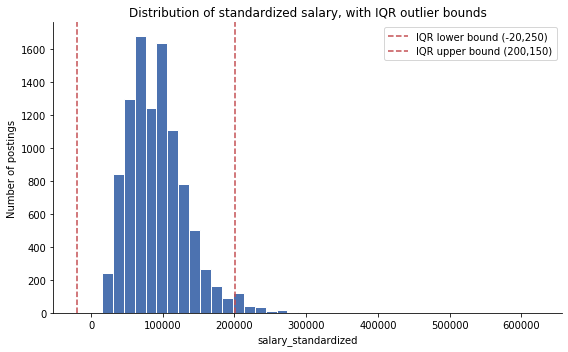

In [22]:
# Histogram of salary_standardized, with the IQR bounds marked as reference
# lines. salary_standardized is used here rather than salary_avg because it's
# already normalized across hourly vs. yearly postings — salary_avg mixes two
# very different scales (e.g. ~20-90 for hourly, ~40,000-150,000 for yearly),
# which would make a single histogram look oddly bimodal and hard to read.
salary_for_hist = df_real[COL_SALARY_STD].dropna()

if len(salary_for_hist) >= 4:
    lower, upper = iqr_outlier_bounds(salary_for_hist)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(salary_for_hist, bins=40, color="#4C72B0", edgecolor="white")
    ax.axvline(lower, color="#C44E52", linestyle="--", linewidth=1.5, label=f"IQR lower bound ({lower:,.0f})")
    ax.axvline(upper, color="#C44E52", linestyle="--", linewidth=1.5, label=f"IQR upper bound ({upper:,.0f})")
    ax.set_xlabel("salary_standardized")
    ax.set_ylabel("Number of postings")
    ax.set_title("Distribution of standardized salary, with IQR outlier bounds")
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print(f"Too few non-null salary_standardized values ({len(salary_for_hist)}) to plot a meaningful histogram.")


## Step 8 — Quick cross-tabs to see how fields interact

In [23]:
# Work-from-home mentions by source board (via_clean)
if "via_clean" in df_real.columns and COL_WFH in df_real.columns:
    wfh_by_via = pd.crosstab(df_real["via_clean"], df_real[COL_WFH].fillna(False))
    print("Work-from-home mentions by job board:")
    display(wfh_by_via)


Work-from-home mentions by job board:


work_from_home,False,True
via_clean,,
1840 & Company - Career Page - JazzHR,0,2
8VC Job Board,0,1
AAAI Career Center,4,0
AARP Job Board,3,0
ACME AtronOmatic,0,1
...,...,...
ZCore Group,0,9
Zest Openings,17,0
ZipRecruiter,2988,183


In [24]:
# Health-insurance mentions by schedule type
if COL_SCHEDULE in df_real.columns and "flag_health_insurance" in df_real.columns:
    health_by_schedule = pd.crosstab(df_real[COL_SCHEDULE], df_real["flag_health_insurance"])
    print("Health-insurance mentions by schedule type:")
    display(health_by_schedule)


Health-insurance mentions by schedule type:


flag_health_insurance,False,True
schedule_type,,
Contractor,8785,499
Contractor and Per diem,4,0
Contractor and Temp work,3071,59
"Contractor, Temp work, and Per diem",0,2
Full-time,25841,19241
Full-time and Contractor,240,109
Full-time and Internship,174,18
Full-time and Part-time,487,700
Full-time and Per diem,6,3


## What to look at next

- Confirm on the full downloaded file whether the mostly-blank-row pattern
  seen here is specific to this sample export, or present throughout — it
  changes how much real data you actually have to work with.
- Verify `date_time` against a few known postings before relying on it for
  any time-based analysis.
- Once salary coverage is large enough to be meaningful, compare
  `salary_standardized` by skill or by `via_clean` (source board).
- Build a proper skills-frequency chart from `top_skills` in Step 6.
- Revisit the `ext_flags` list for any other attributes worth turning into
  their own boolean column (paid time off, dental insurance, etc.), the same
  way `flag_health_insurance` and `flag_no_degree_mentioned` were built.
